Notebook for illustrating the optimizations done in the gradient computation on the restricted state space.

In [24]:
import mhn
from mhn.optimizers import Optimizer, Device
import pandas as pd
import time
import matplotlib.pyplot as plt
import math
import numpy as np

np.random.seed(123)


For performance evaluation we are interested in whether CUDA optimizations are available on our machine

In [25]:
mhn.CUDA_AVAILABLE

'CUDA is available'

In [26]:
opt = Optimizer()
opt.set_penalty(opt.Penalty.L1)
opt.set_device(Device.CPU)

In [27]:
input = pd.read_csv('LUAD_n12.csv')

[477, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

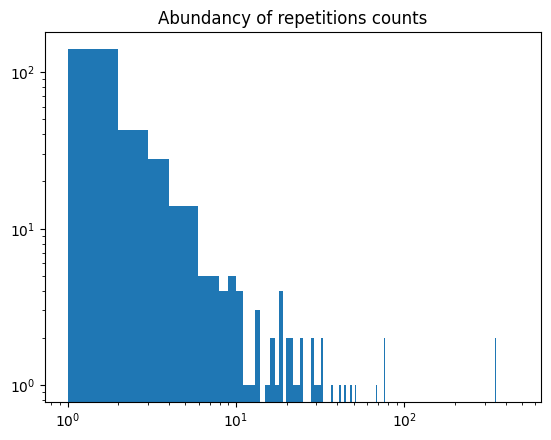

In [43]:
my_data = np.tile(input, (1,1))
opt.load_data_matrix(my_data)
repetitions=opt._data.get_repetition_descriptor()
print(repetitions)
print(sum(repetitions))
print(f"{sum([1 if r==0 else 0 for r in repetitions])} / {len(my_data)} are redundant samples")
plt.hist([r for r in repetitions if r!=0], bins=max(repetitions),)
plt.yscale('log')
plt.xscale('log')
plt.title("Abundancy of repetitions counts")
plt.show()

In [29]:
#test code
opt._data.compress_data()
compr_repetitions = opt._data.get_repetition_descriptor()
print(repetitions)
print(compr_repetitions)
print(len(compr_repetitions))

[3339, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [30]:
print(opt._data.get_max_mutation_num())

6


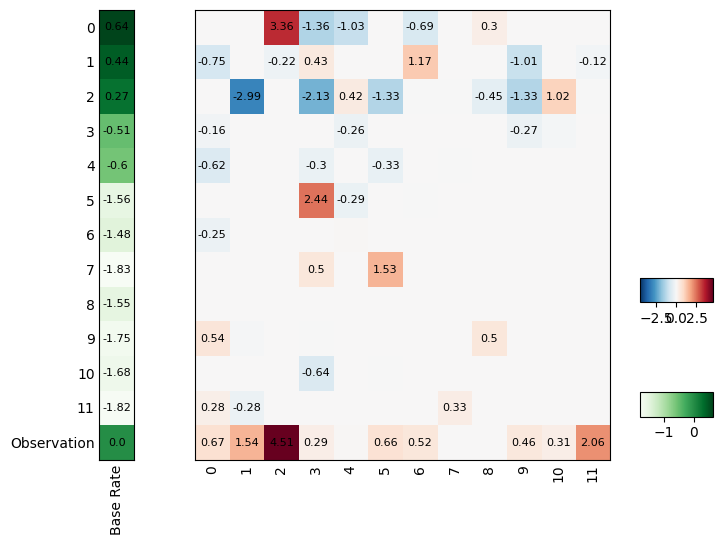

In [31]:
opt.train(5/len(input))
opt.result.plot()
plt.show()

In [32]:
import gc

In [49]:


dataset_fractions = [0.1, 0.25, 0.5, 0.75, 1, 1.5, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
N=len(input)
computation_times={frac:[] for frac in dataset_fractions}

repetitions=5
for i in range(repetitions):
    for dataset_fraction in dataset_fractions:
        input_subset = np.tile(input, (math.ceil(dataset_fraction),1))[:int(N*dataset_fraction)]
        

        #input_subset = input.sample(frac=dataset_fraction, replace=True, random_state=6)
        start_prep = time.process_time()
        opt.load_data_matrix(input_subset)
        opt._data.compress_data()
        end_prep = time.process_time()


        print(f"{dataset_fraction} fraction of dataset ({len(input_subset)}) ")

        start_coll = time.process_time()
        gc.collect()
        end_coll = time.process_time()
        print(f"Garbage collection time: {end_coll-start_coll}")

        #measure time optimization takes
        start = time.process_time()
        
        my_lam = 1.0/len(input_subset)
        if dataset_fraction > 1:
            my_lam = 1.0/N  # fix one value for lambda to have comparable score landscapes (for "full" datasets)
        opt.train(lam = my_lam)      
        end = time.process_time()

        time_elapsed= end-start
        computation_times[dataset_fraction].append(time_elapsed)
        print(f"Preparation time: {end_prep-start_prep}\t CPU time: {time_elapsed} seconds")

0.1 fraction of dataset (366) 
Garbage collection time: 0.125
Preparation time: 0.0	 CPU time: 0.546875 seconds
0.25 fraction of dataset (915) 
Garbage collection time: 0.0625
Preparation time: 0.0	 CPU time: 0.921875 seconds
0.5 fraction of dataset (1831) 
Garbage collection time: 0.078125
Preparation time: 0.0	 CPU time: 1.171875 seconds
0.75 fraction of dataset (2746) 
Garbage collection time: 0.078125
Preparation time: 0.0	 CPU time: 1.671875 seconds
1 fraction of dataset (3662) 
Garbage collection time: 0.09375
Preparation time: 0.0	 CPU time: 2.078125 seconds
1.5 fraction of dataset (5493) 
Garbage collection time: 0.078125
Preparation time: 0.0	 CPU time: 1.640625 seconds
2 fraction of dataset (7324) 
Garbage collection time: 0.078125
Preparation time: 0.0	 CPU time: 2.1875 seconds
3 fraction of dataset (10986) 
Garbage collection time: 0.0625
Preparation time: 0.015625	 CPU time: 1.953125 seconds
4 fraction of dataset (14648) 
Garbage collection time: 0.078125
Preparation time:

In [50]:
comp_times_df=pd.DataFrame.from_dict(computation_times)

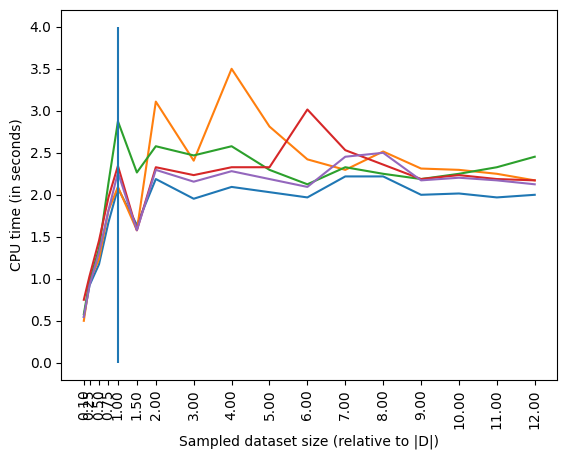

In [53]:
comp_times_df.T.plot(xlabel="Sampled dataset size (relative to |D|)", ylabel="CPU time (in seconds)", xticks=dataset_fractions, legend=False)
plt.xticks(rotation=90)

plt.vlines(1,0,4)

In [52]:
print(opt._data.get_repetition_descriptor())

[5724, 2820, 4188, 2412, 4188, 4896, 12, 12, 336, 336, 912, 288, 12, 24, 372, 180, 816, 216, 912, 348, 24, 24, 36, 192, 60, 384, 252, 108, 48, 444, 264, 576, 120, 12, 24, 48, 12, 48, 108, 12, 12, 120, 96, 612, 108, 84, 60, 12, 36, 36, 240, 12, 48, 204, 48, 48, 24, 12, 12, 24, 84, 24, 12, 12, 24, 48, 252, 72, 96, 108, 144, 60, 72, 72, 12, 12, 36, 24, 24, 72, 60, 120, 12, 60, 36, 288, 12, 12, 12, 24, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 96, 216, 192, 240, 48, 120, 12, 36, 60, 60, 24, 12, 12, 36, 84, 48, 12, 36, 12, 72, 36, 12, 12, 36, 48, 12, 12, 12, 36, 24, 12, 12, 36, 12, 12, 12, 12, 12, 24, 12, 12, 24, 12, 12, 216, 492, 132, 156, 36, 24, 24, 24, 12, 12, 96, 60, 24, 12, 12, 24, 36, 12, 84, 48, 24, 12, 12, 36, 12, 24, 12, 12, 36, 24, 12, 12, 12, 12, 24, 12, 12, 12, 24, 60, 24, 24, 12, 36, 12, 36, 12, 24, 12, 12, 24, 12, 12, 12, 60, 156, 216, 156, 384, 276, 12, 12, 12, 60, 48, 36, 36, 60, 24, 12, 12, 12, 24, 12, 12, 12, 24, 12, 12, 24, 12, 12, 12, 12, 24, 24, 12, 12, 12, 12, 12, 36, 2